In [19]:
from transformers import DistilBertForQuestionAnswering, DistilBertTokenizer , DistilBertModel, RobertaTokenizer, RobertaModel
import torch
import matplotlib as plt
import seaborn as sns
import re


In [2]:
model_name = 'distilbert-base-uncased-distilled-squad'

In [3]:
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForQuestionAnswering.from_pretrained(model_name)


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

In [4]:
question = 'What is the difference between a question and a paragraph with an answer?'
answer_document = 'A question is a sentence that asks for information and usually ends with a question mark. A paragraph with an answer, on the other hand, is a short written explanation that gives the information clearly and completely. For example, if someone asks, “What is a computer?”, the answer paragraph might explain that a computer is an electronic machine that processes data and performs tasks based on instructions.'

In [5]:
encode = tokenizer(question, answer_document)
print(encode)

{'input_ids': [101, 2054, 2003, 1996, 4489, 2090, 1037, 3160, 1998, 1037, 20423, 2007, 2019, 3437, 1029, 102, 1037, 3160, 2003, 1037, 6251, 2008, 5176, 2005, 2592, 1998, 2788, 4515, 2007, 1037, 3160, 2928, 1012, 1037, 20423, 2007, 2019, 3437, 1010, 2006, 1996, 2060, 2192, 1010, 2003, 1037, 2460, 2517, 7526, 2008, 3957, 1996, 2592, 4415, 1998, 3294, 1012, 2005, 2742, 1010, 2065, 2619, 5176, 1010, 1523, 2054, 2003, 1037, 3274, 1029, 1524, 1010, 1996, 3437, 20423, 2453, 4863, 2008, 1037, 3274, 2003, 2019, 4816, 3698, 2008, 6194, 2951, 1998, 10438, 8518, 2241, 2006, 8128, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [6]:
input_ids = encode['input_ids']
tokens = tokenizer.convert_ids_to_tokens(input_ids)

In [7]:
output = model(input_ids = torch.tensor([input_ids]), attention_mask = torch.tensor([encode['attention_mask']]))

In [8]:
start_index = torch.argmax(output.start_logits)
end_index = torch.argmax(output.end_logits)

In [9]:
print(start_index)
print(end_index)

tensor(45)
tensor(55)


In [10]:
answer = ' '.join(tokens[start_index:end_index+1])
print(answer)

a short written explanation that gives the information clearly and completely


In [11]:
s_score = output.start_logits.detach().numpy().flatten()
e_score = output.end_logits.detach().numpy().flatten() 

In [12]:
def arrays_for_plot(score_array):
    token_labels = []
    meaningful_scores = []
    for (i, token) in enumerate(tokens):
        if score_array[i] > 0:
            token_labels.append('{:} - {:>2}'.format(token, i))
            meaningful_scores.append(score_array[i])

    return {'token_labels' : token_labels, 'meaningful_scores' :  meaningful_scores} 

C:\Users\usama\AppData\Local\Temp\ipykernel_2276\607772684.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels( ax.get_xticklabels(), rotation = 90, ha = 'center')


[Text(0, 0, 'a - 33'),
 Text(1, 0, 'paragraph - 34'),
 Text(2, 0, 'an - 36'),
 Text(3, 0, 'answer - 37'),
 Text(4, 0, 'is - 44'),
 Text(5, 0, 'a - 45'),
 Text(6, 0, 'short - 46'),
 Text(7, 0, 'written - 47'),
 Text(8, 0, 'explanation - 48'),
 Text(9, 0, 'that - 49'),
 Text(10, 0, 'gives - 50'),
 Text(11, 0, 'the - 51'),
 Text(12, 0, 'information - 52'),
 Text(13, 0, 'clearly - 53'),
 Text(14, 0, 'completely - 55')]

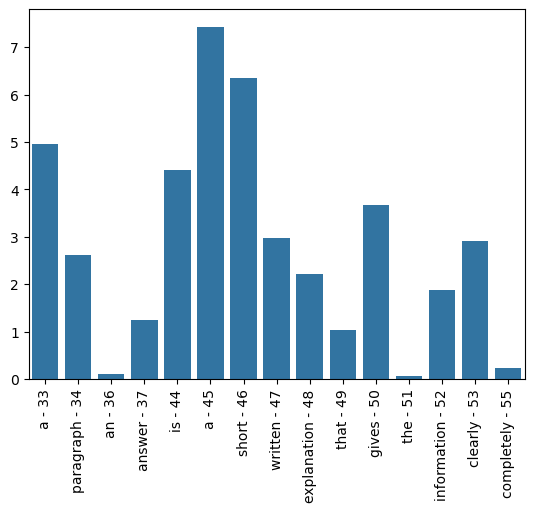

In [13]:
arrs = arrays_for_plot(s_score)
ax = sns.barplot(x= arrs['token_labels'], y= arrs['meaningful_scores'])
ax.set_xticklabels( ax.get_xticklabels(), rotation = 90, ha = 'center')


C:\Users\usama\AppData\Local\Temp\ipykernel_2276\3553088537.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, ha = 'center')


[Text(0, 0, 'written - 47'),
 Text(1, 0, 'explanation - 48'),
 Text(2, 0, 'information - 52'),
 Text(3, 0, 'clearly - 53'),
 Text(4, 0, 'completely - 55'),
 Text(5, 0, '. - 56')]

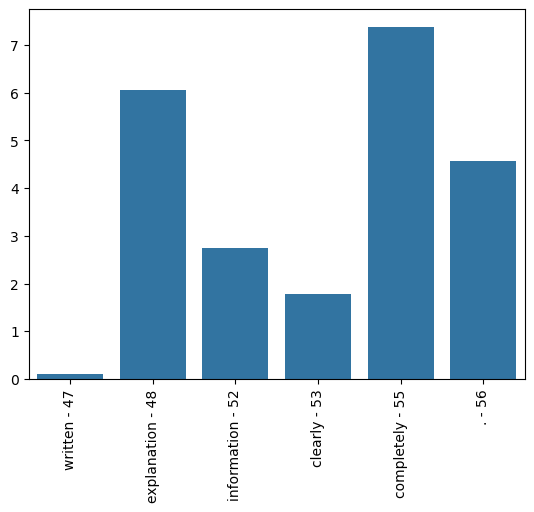

In [14]:
arrs = arrays_for_plot(e_score)
ax = sns.barplot(x= arrs['token_labels'] , y = arrs['meaningful_scores'])
ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, ha = 'center')

In [15]:
answering_document = 'Mafia II is a historical action-adventure video game set in 1940s–50s Empire Bay, where players control Vito Scaletta, a young Sicilian immigrant who rises through the ranks of the city’s organized crime world. The game is played from a third-person perspective and focuses on shooting, driving, and story-driven missions as Vito becomes involved with the Mafia, making choices that shape his criminal career and relationships. It was developed by 2K Czech and published by 2K, and it is known for its cinematic storytelling, strong atmosphere, and immersive period setting. The game features a large open world, various weapons, vehicle-based missions, and a campaign that blends action with character drama. Mafia II is generally rated for mature audiences because of violence, strong language, and some adult themes, and it is often praised for its story, soundtrack, and detailed recreation of the era, though it is not a multiplayer game and is primarily a single-player experience.'

In [16]:
def faqbot(question):
    context = answering_document
    encode = tokenizer(question, context)
    tokens = tokenizer.convert_ids_to_tokens(encode['input_ids'])
    sep_index = encode['input_ids'].index(tokenizer.sep_token_id)
    q = sep_index+1
    a = len(encode['input_ids']) - q
    segment_ids = [0]*q + [1]*a
    output = model(input_ids = torch.tensor([encode['input_ids']]), token_type_ids = torch.tensor([segment_ids]))
    start_index = torch.argmax(output.start_logits)
    end_index = torch.argmax(output.end_logits)
    if(start_index >= end_index):
        print("sorry , I don't have any knowledge about this")
    else:
        answer = ' '.join(tokens[start_index:end_index])
        answer = re.sub(' ##', '', answer)
        print(answer)


faqbot('when was mafia 2 released ?')

2


In [20]:
model = 'roberta-base'
robertTokenizer = RobertaTokenizer.from_pretrained(model)
RobertaModel = RobertaModel.from_pretrained(model)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

e:\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in E:\huggingface_cache\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
